# Visualisation

Visualises NLI strategy performance.
It compares strategies on overall Accuracy and Macro-F1, then breaks performance down by class-level F1 and error-type distributions.
It also analyzes hybrid threshold selection (accuracy vs CE coverage) and summarises the cost-accuracy trade-off to support practical model selection decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

In [ ]:
xl = pd.read_excel('nli_comparison.xlsx', sheet_name=None)

df_all     = xl['All Strategies']
df_detail  = xl['Per-Class Detail']
df_error   = xl['Error Analysis']
df_thresh  = xl['Threshold Selection']

display(df_all)

,Strategy,Type,Samples,Accuracy,Macro-F1,Contra-F1,Entail-F1,Neutral-F1,Neutral Recall,Total Errors,API Calls,Cost ($)
0,Pure Zero-Shot,Pure LLM,2000,0.8260,0.8230,0.83,0.89,0.75,0.8007,348,2000,0.0317
1,Pure Few-Shot,Pure LLM,2000,0.8355,0.8305,0.88,0.87,0.74,0.7199,329,2000,0.0502
2,Pure CoT,Pure LLM,2000,0.8465,0.8479,0.86,0.90,0.79,0.8830,307,2000,0.1070
3,CE Only,Baseline,2000,0.8395,0.8400,0.86,0.86,0.79,0.8100,321,0,0.0000
4,Hybrid + Zero-Shot,Hybrid,2000,0.8765,0.8700,0.89,0.90,0.83,0.8400,247,474,0.0075
5,Hybrid + Few-Shot,Hybrid,2000,0.8775,0.8700,0.91,0.89,0.82,0.8100,245,474,0.0119
6,Hybrid + CoT,Hybrid,2000,0.8820,0.8800,0.90,0.91,0.84,0.8700,236,474,0.0259
7,Pure ZS-Rep,Repetition,2000,0.8210,0.8196,0.82,0.89,0.75,0.8320,358,2000,0.0609
8,Pure FS-Rep,Repetition,2000,0.8425,0.8393,0.88,0.88,0.76,0.7694,315,2000,0.0981
9,Hybrid ZS-Rep,Hybrid+Rep,2000,0.8745,0.8729,0.89,0.90,0.83,0.8517,251,474,0.0145


In [36]:
strategies = df_all['Strategy'].tolist()
accuracy   = df_all['Accuracy'].tolist()
macro_f1   = df_all['Macro-F1'].tolist()

# Pure ZS mark as baseline
type_color_map = {
    'Pure LLM':   '#4472C4',
    'Baseline':   '#696969',
    'Hybrid':     '#ED7D31',
    'Repetition': '#70AD47',
    'Hybrid+Rep': '#FFC000',
}
colors = []
for i, (strat, t) in enumerate(zip(df_all['Strategy'], df_all['Type'])):
    if strat == 'Pure Zero-Shot':
        colors.append('#A9A9A9')   # baseline grey
    else:
        colors.append(type_color_map.get(t, '#888888'))

legend_handles = [
    mpatches.Patch(color='#A9A9A9', label='Baseline (Pure ZS)'),
    mpatches.Patch(color='#4472C4', label='Pure LLM'),
    mpatches.Patch(color='#696969', label='CE Model'),
    mpatches.Patch(color='#ED7D31', label='Hybrid'),
    mpatches.Patch(color='#70AD47', label='Pure+Rep'),
    mpatches.Patch(color='#FFC000', label='Hybrid+Rep'),
]


x_labels = df_detail['Strategy'].tolist()
x = np.arange(len(strategies))

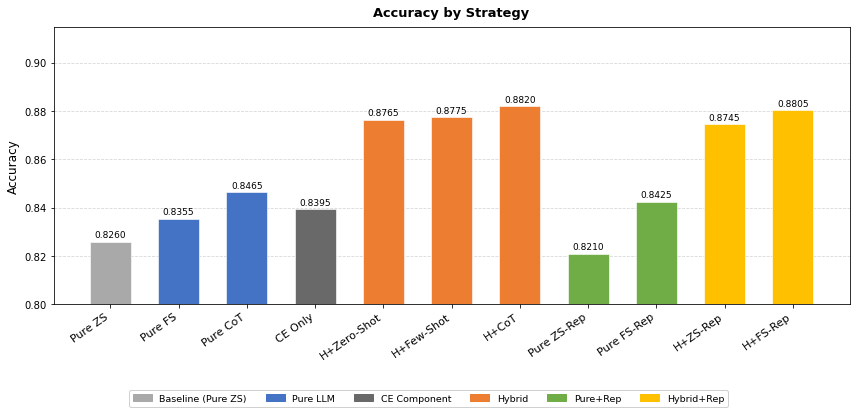

In [4]:
w = 0.6
fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(x, accuracy, width=w, color=colors, edgecolor='white', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=11)
ax.set_ylim(0.80, 0.915)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy by Strategy', fontsize=13, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
for bar, v in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0008,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
fig.legend(handles=legend_handles, loc='lower center', ncol=6,
           fontsize=9.5, bbox_to_anchor=(0.5, -0.05),
           framealpha=0.9, edgecolor='#cccccc')
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('figures/fig1a_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()

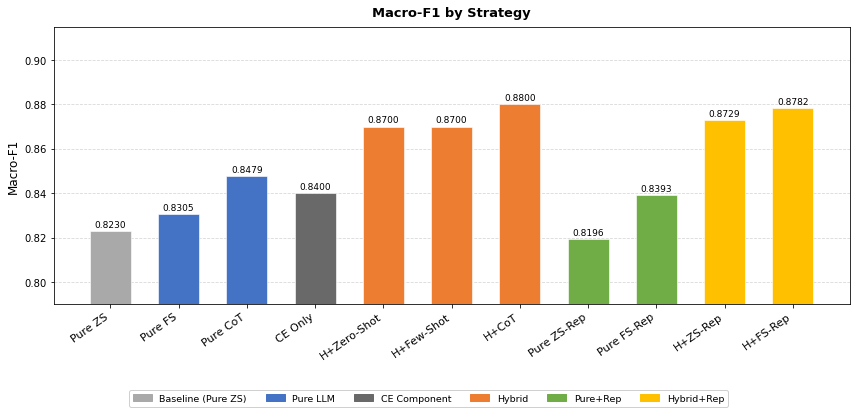

In [5]:
fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(x, macro_f1, width=w, color=colors, edgecolor='white', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=11)
ax.set_ylim(0.79, 0.915)
ax.set_ylabel('Macro-F1', fontsize=12)
ax.set_title('Macro-F1 by Strategy', fontsize=13, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
for bar, v in zip(bars, macro_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0008,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
fig.legend(handles=legend_handles, loc='lower center', ncol=6,
           fontsize=9.5, bbox_to_anchor=(0.5, -0.05),
           framealpha=0.9, edgecolor='#cccccc')
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('figures/fig1b_macrof1.png', dpi=200, bbox_inches='tight')
plt.show()

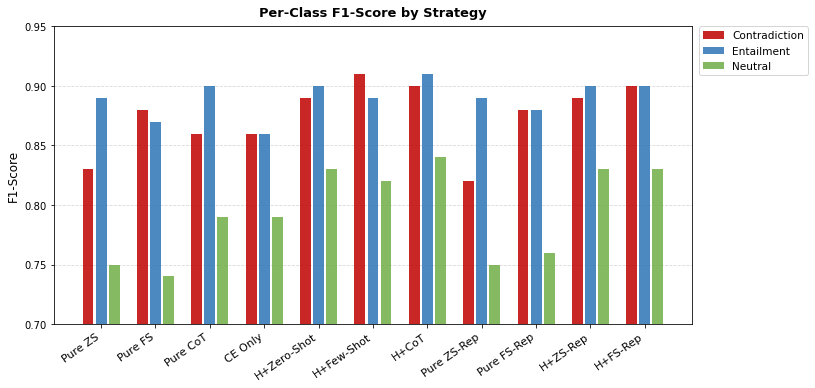

In [27]:
contra_f1 = df_detail['Contra-F1'].tolist()
entail_f1 = df_detail['Entail-F1'].tolist()
neutral_f1= df_detail['Neutral-F1'].tolist()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(x - w/3*1.2, contra_f1, width=w/3, label='Contradiction', color='#C00000', alpha=0.85)
ax.bar(x,            entail_f1, width=w/3, label='Entailment',    color='#2E75B6', alpha=0.85)
ax.bar(x + w/3*1.2,  neutral_f1,width=w/3, label='Neutral',       color='#70AD47', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=11)
ax.set_ylim(0.70, 0.95)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score by Strategy', fontsize=13, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10.5, loc='upper left',
          bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('figures/fig2_perclass_f1.png', dpi=200, bbox_inches='tight')
plt.show()

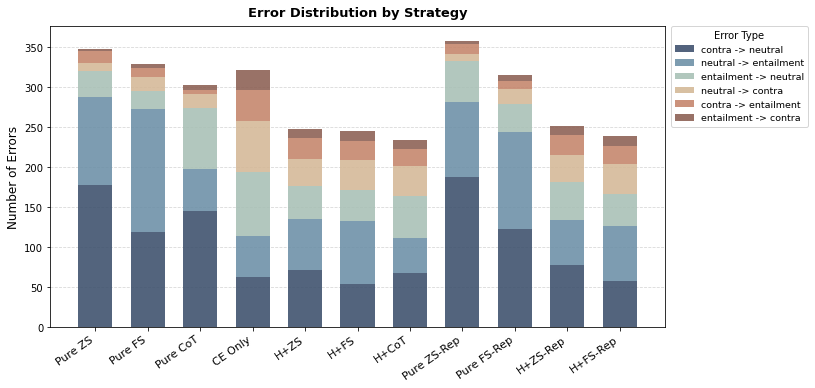

In [39]:
df_err = df_error.set_index('Error Type').drop(columns='Total', errors='ignore')
df_err = df_err.drop(index=['* -> error', 'Total'], errors='ignore')

palette = ['#3B4F6B', '#6B8FA6', '#A8C0B5', '#D4B896', '#C4846A', '#8B5E52', '#ABABAB']
fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(len(df_err.columns))
for row_label, color in zip(df_err.index, palette):
    vals = df_err.loc[row_label].values.astype(float)
    ax.bar(range(len(df_err.columns)), vals, bottom=bottom,
           label=row_label, color=color, alpha=0.88, width=0.65)
    bottom += vals
ax.set_xticks(range(len(df_err.columns)))
ax.set_xticklabels(df_err.columns, rotation=35, ha='right', fontsize=11)
ax.set_ylabel('Number of Errors', fontsize=12)
ax.set_title('Error Distribution by Strategy', fontsize=13, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(title='Error Type', fontsize=9.5,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('figures/fig3_error_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

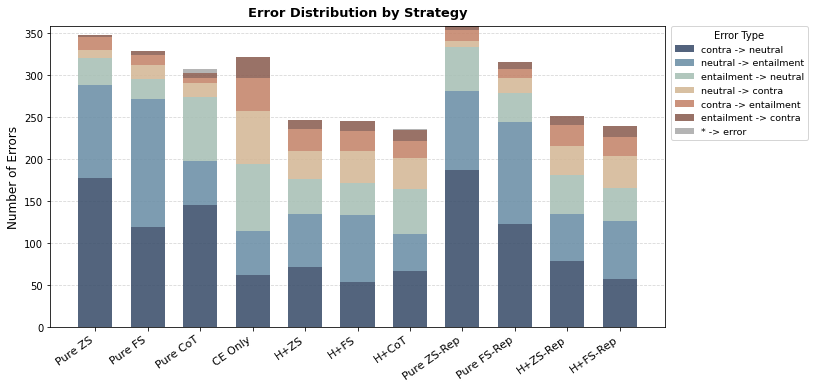

In [40]:
df_err = df_error.set_index('Error Type').drop(columns='Total', errors='ignore')

palette = ['#3B4F6B', '#6B8FA6', '#A8C0B5', '#D4B896', '#C4846A', '#8B5E52', '#ABABAB']
fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(len(df_err.columns))
for row_label, color in zip(df_err.index, palette):
    vals = df_err.loc[row_label].values.astype(float)
    ax.bar(range(len(df_err.columns)), vals, bottom=bottom,
           label=row_label, color=color, alpha=0.88, width=0.65)
    bottom += vals
ax.set_xticks(range(len(df_err.columns)))
ax.set_xticklabels(df_err.columns, rotation=35, ha='right', fontsize=11)
ax.set_ylabel('Number of Errors', fontsize=12)
ax.set_title('Error Distribution by Strategy', fontsize=13, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(title='Error Type', fontsize=9.5,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('figures/fig3_error_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

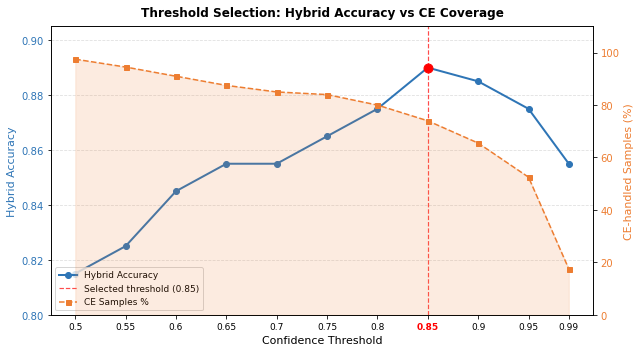

In [24]:
thresholds = df_thresh['Threshold'].tolist()
hybrid_acc = df_thresh['Hybrid Accuracy'].tolist()
ce_pct     = df_thresh['CE %'].str.replace('%','').astype(float).tolist()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(thresholds, hybrid_acc, 'o-', color='#2E75B6',
         linewidth=2, markersize=6, label='Hybrid Accuracy')
ax1.axvline(0.85, color='red', linestyle='--', linewidth=1.2,
            alpha=0.7, label='Selected threshold (0.85)')
ax1.scatter([0.85], [df_thresh.loc[df_thresh['Threshold']==0.85, 'Hybrid Accuracy'].values[0]],
            color='red', zorder=5, s=80)
ax1.set_xlabel('Confidence Threshold', fontsize=11)
ax1.set_ylabel('Hybrid Accuracy', fontsize=11, color='#2E75B6')
ax1.tick_params(axis='y', labelcolor='#2E75B6')
ax1.set_ylim(0.80, 0.905)
ax1.set_xticks(thresholds)
ax1.set_xticklabels([f'{t}' if t != 0.85 else '0.85' for t in thresholds], fontsize=9)
# 让0.85的tick标签变红
for tick, t in zip(ax1.get_xticklabels(), thresholds):
    if t == 0.85:
        tick.set_color('red')
        tick.set_fontweight('bold')

ax2 = ax1.twinx()
ax2.fill_between(thresholds, ce_pct, alpha=0.15, color='#ED7D31')
ax2.plot(thresholds, ce_pct, 's--', color='#ED7D31',
         linewidth=1.5, markersize=5, label='CE Samples %')
ax2.set_ylabel('CE-handled Samples (%)', fontsize=11, color='#ED7D31')
ax2.tick_params(axis='y', labelcolor='#ED7D31')
ax2.set_ylim(0, 110)

ax1.set_title('Threshold Selection: Hybrid Accuracy vs CE Coverage',
              fontsize=12, fontweight='bold', pad=10)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')
fig.tight_layout()
plt.savefig('figures/fig4_threshold.png', dpi=200, bbox_inches='tight')
plt.show()

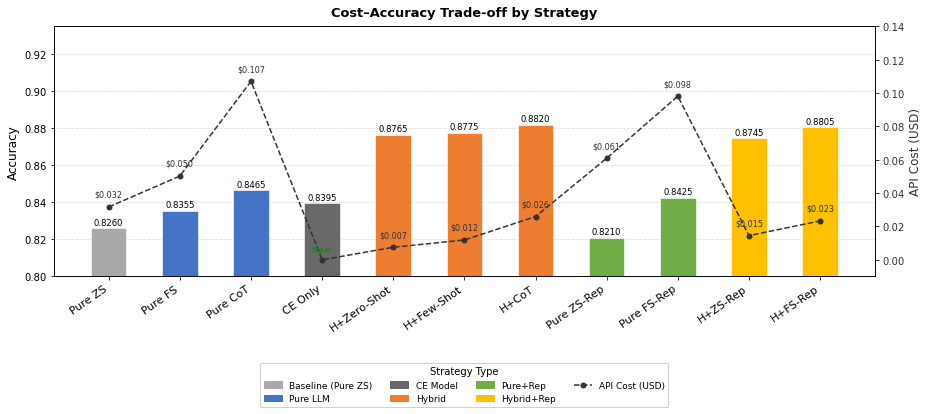

In [37]:
import matplotlib.lines as mlines

cost = df_detail['Cost ($)'].tolist()

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax2 = ax1.twinx()

bars = ax1.bar(x, accuracy, width=0.5, color=colors, edgecolor='white', linewidth=0.6, zorder=2)
ax1.set_ylim(0.80, 0.935)
ax1.set_ylabel('Accuracy', fontsize=12)

ax2.plot(x, cost, 'o--', color='#333333', linewidth=1.5, markersize=5, zorder=3)
ax2.set_ylabel('API Cost (USD)', fontsize=12, color='#333333')
ax2.tick_params(axis='y', labelcolor='#333333')
ax2.set_ylim(-0.01, 0.14)

for bar, v in zip(bars, accuracy):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0008,
             f'{v:.4f}', ha='center', va='bottom', fontsize=8.5)

for xi, (c, lbl) in enumerate(zip(cost, x_labels)):
    if c > 0:
        ax2.annotate(f'${c:.3f}', (xi, c),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center',
                     fontsize=8, color='#333333')
    else:
        ax2.annotate('free', (xi, c),
                     textcoords='offset points',
                     xytext=(0, 8), ha='center',
                     fontsize=8.5, color='#2E7D32', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=11)
ax1.set_title('Cost–Accuracy Trade-off by Strategy', fontsize=13, fontweight='bold', pad=10)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)

cost_line = mlines.Line2D([], [], color='#333333', linestyle='--',
                           marker='o', markersize=5, label='API Cost (USD)')
fig.legend(handles=legend_handles + [cost_line], loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05),
           framealpha=0.9, edgecolor='#cccccc', title='Strategy Type')

fig.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig('figures/fig5_cost_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()